# 🧠 Mental Health in Tech
## 0. Overview
In this notebook we will be thoroughly analyzing mental health data and perceptions in the tech industry in the late 2010's. Using SQL, data from 2014 up to 2019 is used and filtered. The data is available from Open Source Mental Illness (OSMI)'s [dataset](https://www.kaggle.com/datasets/anth7310/mental-health-in-the-tech-industry): "Mental Health in the Tech Industry" 

### 🎯 Objectives:
1. Primary area of interest will be the **most prevalent mental conditions** 
    - what condition is most prevalent? 
    - and among the different roles, does prevalence differ? 

2. Second, we will observe the **bearing of a company's size on mental health support** and perception among employees, exploring correlations and perceptions on how the tech industry supports mental health overall.

### Key Findings:
- Most prominent mental condition was **Mood Disorder with a 29% prevalence rate** across this population
- Looking at different roles in tech:
  - Different roles could have higher prevalence in other conditions but Mood Disorder is still prevalent
- Larger size of companies correlates to more mental health benefits, resources, etc
    - Presence of the above did not however, make employees actually feel that their company placed importance on mental health
    - It may be that mental health resources offered by the company are more of formalities
- Overall, despite provided benefits and resources: more efforts were needed in the late 2010s to better support mental health in to the industry

### Importing

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

%matplotlib inline
import seaborn as sns

sns.set_style("darkgrid")
sns.set_context(
    "notebook",
    rc={"axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11})

In [81]:
import sqlite3 as sql

database = "database/mental_health.sqlite"
con = sql.connect(database)

## Overview of Database

In [82]:
tables = ["Question", "Answer", "Survey"]

for table in tables:
    row_count = pd.read_sql(f"SELECT COUNT(*) AS total FROM {table}", con).iloc[0, 0]
    columns = pd.read_sql(f"SELECT * FROM {table} LIMIT 0", con).columns
    print(f"{table} db shape: ({row_count}, {len(columns)})")

Question db shape: (105, 2)
Answer db shape: (236898, 4)
Survey db shape: (5, 2)


We can surmise what the Question and Answer databases contain, what about the Survey table?

In [83]:
query = """SELECT * 
           FROM Survey"""

run_sql = pd.read_sql(query, con)
run_sql

,SurveyID,Description
0,2014,mental health survey for 2014
1,2016,mental health survey for 2016
2,2017,mental health survey for 2017
3,2018,mental health survey for 2018
4,2019,mental health survey for 2019


The **Survey** table contains labelling and IDs of the **year** conducted.

### Questions

In [ ]:
query = """
        SELECT 
            q.questionid,
            q.questiontext,
            GROUP_CONCAT(DISTINCT a.SurveyID) AS years_asked
        FROM Question q
        JOIN Answer a 
            ON q.questionid = a.QuestionID
        GROUP BY 
            q.questionid, q.questiontext
        ORDER BY 
            q.questionid
        """

questions_list = pd.read_sql(query, con)
questions_list.head()

,questionid,questiontext,years_asked
0,1,What is your age?,"2014,2016,2017,2018,2019"
1,2,What is your gender?,"2014,2016,2017,2018,2019"
2,3,What country do you live in?,"2014,2016,2017,2018,2019"
3,4,"If you live in the United States, which state ...","2014,2016,2017,2018,2019"
4,5,Are you self-employed?,"2014,2016,2017,2018,2019"


There are over 100 questions (105) amongst the surveys, and after careful deliberation, only a select few questions were filtered for the use of this notebook and research.

The specific areas of interest will be: 
1. Sociodemographical Data
    1. Age
    2. Gender
    3. Country of Residence
    4. Race
2. Tech Roles
3. Mental Conditions among respondents
4. Prevalence Rates of Conditions 
    * Overall prevalence
    * Prevalence among different tech roles

And more specific **tech industry - mental health** chosen areas of interest:
1. Company Size effects on Mental Health Systems
2. Presence of Mental Health Benefits, Resources
3. Perceptions on the Tech Industry and Support for Mental Health
4. Openness to Mental Health Help over the years

In [85]:
query = """
        WITH questions AS (
                SELECT SurveyID AS year,
                       COUNT(DISTINCT QuestionID) AS num_questions
                FROM Answer
                GROUP BY SurveyID
                ORDER BY SurveyID
        ), respondents AS (
                SELECT SurveyID AS year, 
                       COUNT(DISTINCT UserID) AS num_respondents
                FROM Answer
                WHERE QuestionID = 2
                GROUP BY SurveyID        
        ) SELECT 
                r.year,
                q.num_questions,
                r.num_respondents
        FROM respondents r
        JOIN questions q ON r.year = q.year
        ORDER BY r.year                
        """

df_survey = pd.read_sql_query(query, con)
df_survey

,year,num_questions,num_respondents
0,2014,26,1260
1,2016,60,1433
2,2017,76,756
3,2018,76,417
4,2019,76,352


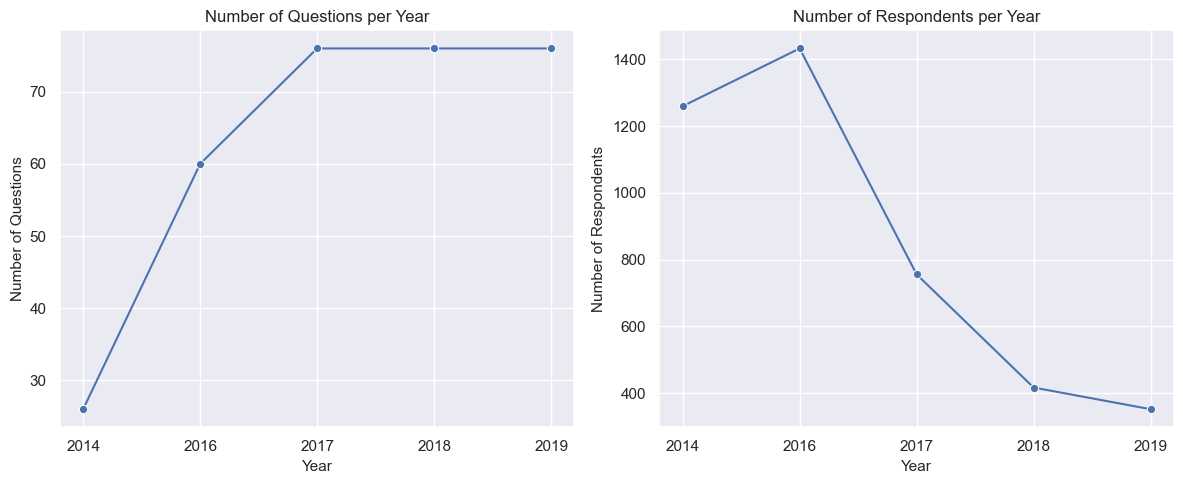

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.set_theme(style="darkgrid")

sns.lineplot(
    df_survey, x=df_survey["year"].astype(str), y="num_questions", ax=ax[0], marker="o"
)
ax[0].set_title("Number of Questions per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Questions")


sns.lineplot(
    df_survey,
    x=df_survey["year"].astype(str),
    y="num_respondents",
    ax=ax[1],
    marker="o",
)
ax[1].set_title("Number of Respondents per Year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

Over the years, the number of questions asked has considerably increased since 2014, and 76 questions became the standard since 2017.

*Note that while 76 is a standard amount of questions, the actual questions still varied year by year.*

Inversely, the number of respondents has a decreasing trend. Keep in mind that we are working with **smaller samples** in later years.

---
## 🌏 1. Sociodemographical Analysis

Questions in use in this section:
- Age - (#1) What is your age?
- Gender - (#2) What is your gender?
- Country - (#3) What country do you live in?
- Race - (#89) What is your race?


### 1.1 Age

#### 1.1.1 Distribution of All Ages

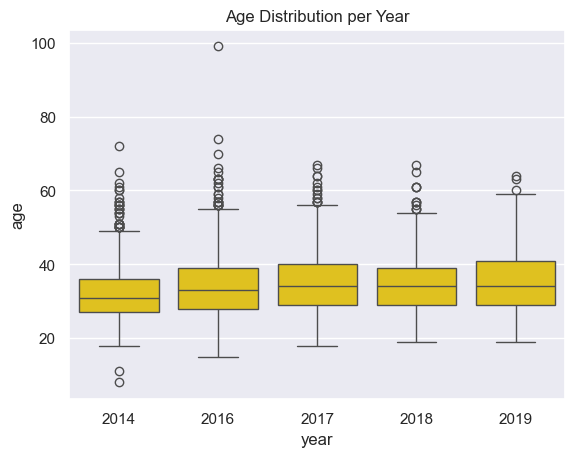

In [ ]:
query = """SELECT SurveyID AS year,
                  CAST(AnswerText AS INTEGER) AS age
            FROM Answer
            WHERE QuestionID = 1
            AND CAST(AnswerText AS INTEGER) BETWEEN 6 AND 99
            ORDER BY SurveyID, age
        """

df_ages_all = pd.read_sql(query, con)

sns.set_style("darkgrid")
sns.boxplot(df_ages_all, x="year", y="age", color="gold")
plt.title("Age Distribution per Year")

The mean age of respondents tends to be 30 and above. 

Curiously there are some outliers in the first 2014 survey, with such low ages that do not align with the supposed population of those working in the tech industry - supposedly adults.

#### 1.1.2 By **Age Group**

In [88]:
query = """
        WITH age_group AS(
            SELECT SurveyID AS year,
                CASE
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 18 AND 24 THEN '18-24'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 25 AND 34 THEN '25-34'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 35 AND 44 THEN '35-44'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 45 AND 54 THEN '45-54'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 55 AND 64 THEN '55-64'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 65 AND 99 THEN '65+'
                END AS age_group,
                COUNT(*) AS count
            FROM Answer
            WHERE QuestionID = 1
                AND CAST(AnswerText AS INTEGER) BETWEEN 18 AND 99
            GROUP BY SurveyID, age_group
            )
            
        SELECT *
        FROM age_group
        """

df_ages = pd.read_sql(query, con)
df_ages = df_ages.pivot(index="year", columns="age_group", values="count").fillna(0)
df_ages = df_ages.astype(int)
df_ages.head()

age_group,18-24,25-34,35-44,45-54,55-64,65+
year,,,,,,
2014,156,707,321,51,15,2
2016,123,710,442,118,31,5
2017,60,339,256,81,16,2
2018,26,187,156,36,10,2
2019,29,147,114,50,11,0


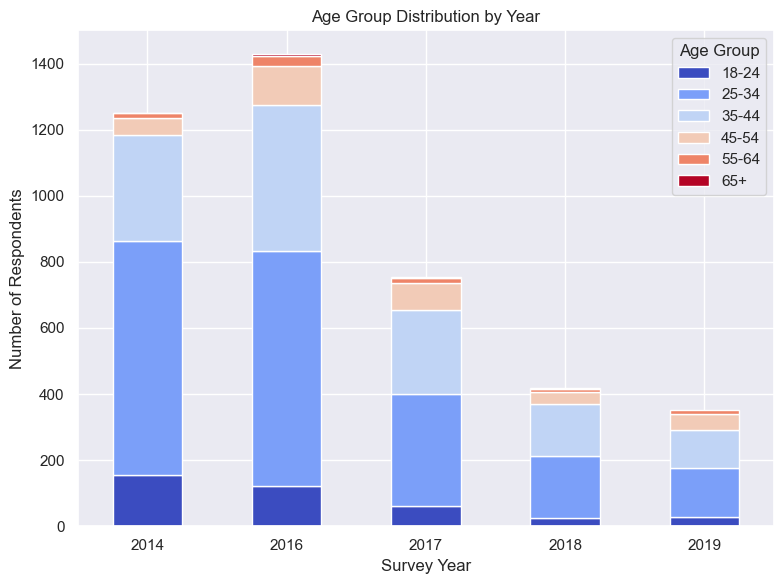

In [89]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.set_style("darkgrid")

df_ages.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm")

ax.set_ylabel("Number of Respondents")
ax.set_xlabel("Survey Year")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title("Age Group Distribution by Year")

labels_legend = df_ages.columns.tolist()
ax.legend(labels=labels_legend, title="Age Group")

plt.tight_layout()
plt.show()

In terms of age groups, majority of respondents fall within the age group of 25-34 and secondly 35-44. This is in line with the overarching focus on the tech industry and working adults.

### 1.2 Gender

In [90]:
query = """
        SELECT  
                SurveyID AS year, 
                AnswerText AS gender, 
                COUNT(*) AS count
        FROM Answer
        WHERE QuestionID = 2
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, count DESC"""

df_gender = pd.read_sql(query, con)
df_gender.head()

,year,gender,count
0,2014,Male,991
1,2014,Female,247
2,2014,Female (trans),2
3,2014,something kinda male?,1
4,2014,queer/she/they,1


This question allowed for open responses, leading to data that needed to be cleaned:

#### Data Cleaning for gender category

In [91]:
def categorize_gender(text):
    if not isinstance(text, str):
        return "other"

    t = text.lower()

    female = ["female", "woman", "afab", "girl", "f", "fem", "mtf", "she", "her"]
    male = ["male", "man", "amab", "boy", "guy", "m", "masc", "ftm", "he", "him"]

    if any(re.search(rf"\b{w}\b", t) for w in male):
        return "male"
    elif any(re.search(rf"\b{w}\b", t) for w in female):
        return "female"
    else:
        return "other"

In [92]:
df_gender["gender"] = df_gender["gender"].apply(categorize_gender)
df_gender = df_gender.groupby(["year", "gender"])["count"].sum().reset_index()

df_gender["percent"] = (
    df_gender["count"] / df_gender.groupby("year")["count"].transform("sum") * 100
).round(1)
df_gender.head()

,year,gender,count,percent
0,2014,female,252,20.0
1,2014,male,996,79.0
2,2014,other,12,1.0
3,2016,female,345,24.1
4,2016,male,1060,74.0


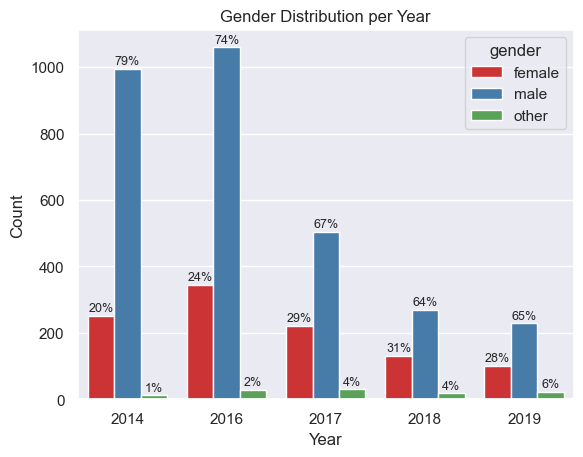

In [ ]:
ax = sns.barplot(
    df_gender, x="year", y="count", hue="gender", errorbar=None, palette="Set1"
)
sns.set_style("darkgrid")

percent_labels = df_gender["percent"].round(0).astype(int).astype(str) + "%"

ax.bar_label(
    ax.containers[0],
    labels=percent_labels[df_gender["gender"] == "female"].values,
    padding=1,
    fontsize=9,
)
ax.bar_label(
    ax.containers[1],
    labels=percent_labels[df_gender["gender"] == "male"].values,
    padding=1,
    fontsize=9,
)
ax.bar_label(
    ax.containers[2],
    labels=percent_labels[df_gender["gender"] == "other"].values,
    padding=1,
    fontsize=9,
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Gender Distribution per Year")

Predominantly the survey population is male - with up to 64% to almost 80% per year being male

*(For the remaining 2 demographical analysis (country & race), only years 2017 to 2019 will be selected to match where both questions are present)*

### 1.3 Country Demographics

The queries and plot below observes the top 10 countries of residences per years 2017 to 2019 amongst all respondents

In [94]:
query = """
        SELECT  
                SurveyID AS year, 
                AnswerText AS country, 
                COUNT(*) AS count
        FROM Answer
        WHERE QuestionID = 3
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, count DESC
        """

df_country = pd.read_sql(query, con)
df_country["country"] = df_country["country"].replace(
    {"United States": "United States of America"}
)
df_country.head()

,year,country,count
0,2014,United States of America,751
1,2014,United Kingdom,185
2,2014,Canada,72
3,2014,Germany,45
4,2014,Netherlands,27


In [95]:
select_years = [2017, 2018, 2019]

top10_countries = (
    df_country[df_country["year"].isin(select_years)].groupby("year").head(10)
)

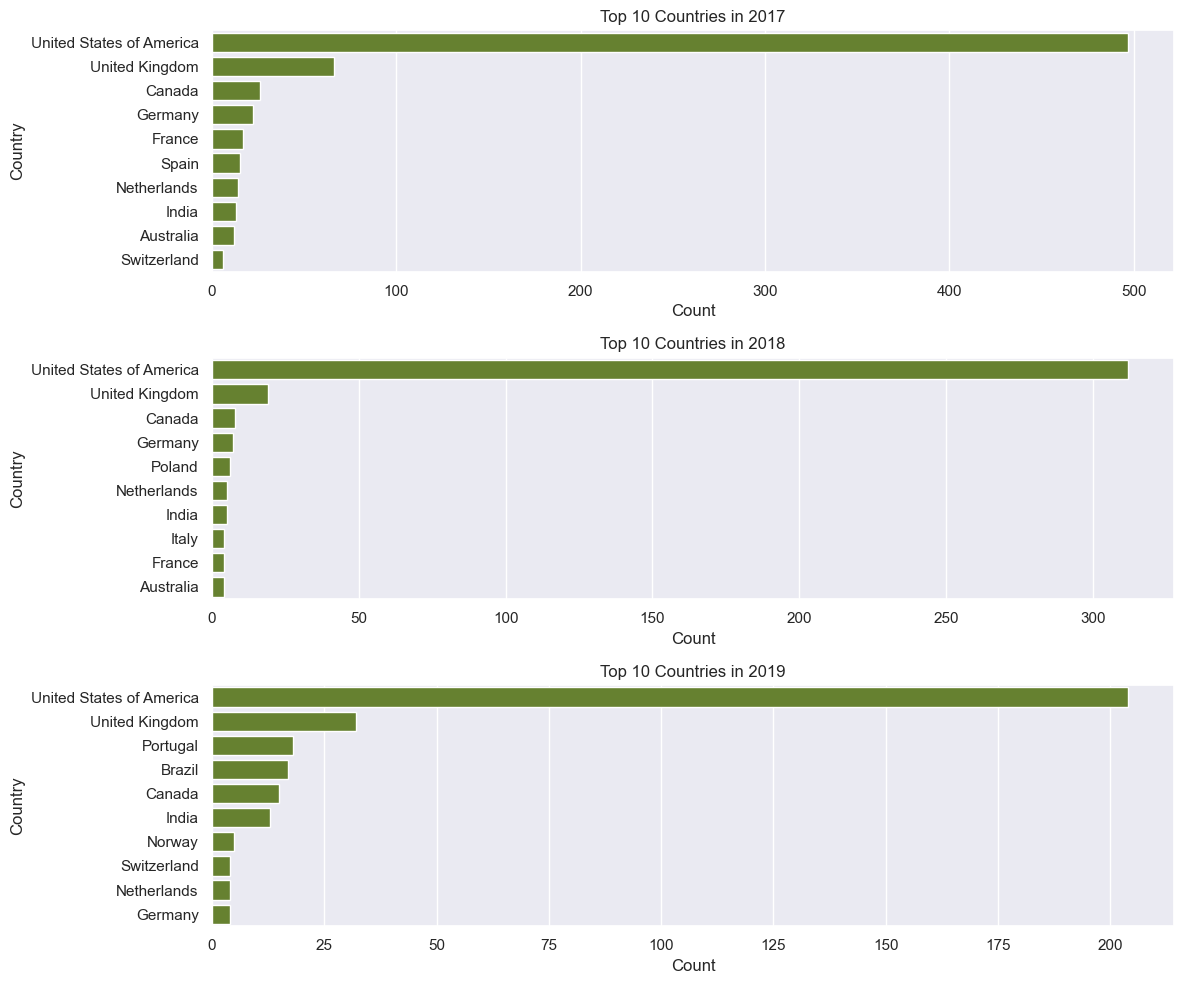

In [96]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, year in enumerate(select_years):
    subset = top10_countries[top10_countries["year"] == year]
    sns.barplot(data=subset, x="count", y="country", ax=axes[i], color="olivedrab")
    axes[i].set_title(f"Top 10 Countries in {year}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Country")

plt.tight_layout()
plt.show()

The survey sampled an overwhelming part of the population from the USA in every observable year, with UK consistently second.

### 1.4 Race Demographics

*Note: This question was only gathered in 2017 onwards.*

In [97]:
query = """
        WITH Race AS (
            SELECT 
                SurveyID AS year, 
                CASE
                    WHEN AnswerText IN ('-1', 'I prefer not to answer') THEN 'N/A'
                    WHEN AnswerText IN ('White Hispanic', 'European American', 'More than one of the above') THEN 'Mixed'
                    ELSE AnswerText
                END AS race
            FROM Answer
            WHERE QuestionID = 89
        )

        SELECT year, race, COUNT(*) AS count
        FROM Race
        GROUP BY year, race
        ORDER BY year, count DESC
        """

df_race = pd.read_sql(query, con)
df_race.head()

,year,race,count
0,2017,White,435
1,2017,N/A,288
2,2017,Mixed,14
3,2017,Asian,13
4,2017,Black or African American,6


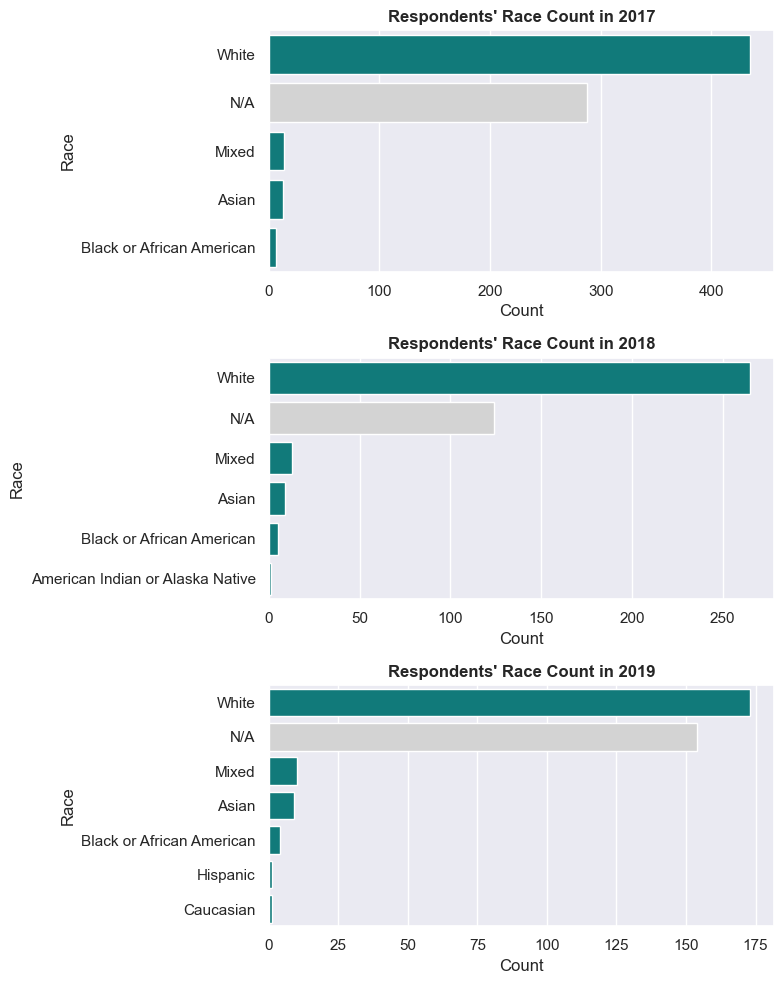

In [98]:
years = df_race["year"].unique()
years.sort()

fig, axes = plt.subplots(len(years), 1, figsize=(8, 10))

for i, year in enumerate(years):
    subset = df_race[df_race["year"] == year]
    colors = ["darkcyan" if j != 1 else "lightgray" for j in range(len(subset))]
    sns.barplot(
        data=subset, x="count", y="race", hue="race", ax=axes[i], palette=colors
    )
    axes[i].set_title(f"Respondents' Race Count in {year}", weight="bold")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Race")

plt.tight_layout()
plt.show()

Interestingly enough, a large percent chose not to answer this question. 

Where data is not null, the population race is made up of mostly respondents considered *white*

### ⚠️ Population Metrics and **Biases**

From all the analysis above, it is important to note that this dataset is found to be:
- **unrepresentative** and has **sampling biases** 
    - with heavy counts leaning towards a specific population and location in terms of gender, race, and country. 
    - Respondents are predominantly male, white, and American. 
- Overall we cannot say that this dataset is representative of a diverse population.

Another area of concern are major points of **inconsistency**. The sampling body and survey timelines are not consistent, missing the year 2015, and questions vary heavily across the years.

---
## 2. Mental Health in Tech

### 2.1 Proportion of Tech : Non-Tech participants

Question of focus:
- (#9) Is your employer primarily a tech company/organization?

In [99]:
query = """
        SELECT 
                SurveyID AS year, 
                AnswerText AS tech_company, 
                COUNT(AnswerText) AS count
        FROM Answer
        WHERE QuestionID = 9 AND AnswerText != -1
        GROUP BY year, AnswerText
        """

df = pd.read_sql(query, con)

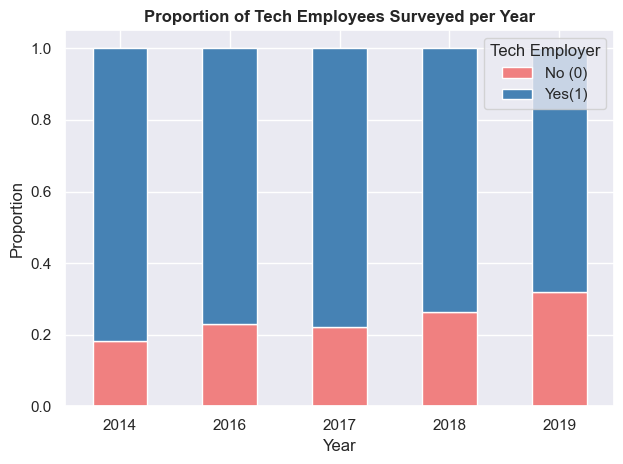

In [119]:
df["prop"] = df["count"] / df.groupby("year")["count"].transform("sum")

df_pivot = df.pivot(index="year", columns="tech_company", values="prop").fillna(0)

sns.set_theme(style="darkgrid")

df_pivot.plot(kind="bar", stacked=True, color=["lightcoral", "steelblue"])

plt.title("Proportion of Tech Employees Surveyed per Year", weight="bold")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.ylabel("Proportion")
plt.legend(title="Tech Employer", labels=["No (0)", "Yes(1)"])
plt.tight_layout()
plt.show()

Proportionally this is in line with the supposed target group for Mental Health in Tech, of workers in the tech industry.

### 2.2 Roles of Respondents
* (#117) Which of the following best describes your work position?

*Note: Data for this question is only available for **2016***

In [101]:
query = """
        SELECT 
                AnswerText AS role, 
                COUNT(AnswerText) AS count
        FROM Answer 
        WHERE QuestionID = 117
        GROUP BY AnswerText
        """

df_roles = pd.read_sql(query, con)
df_roles = df_roles.sort_values("count", ascending=False)

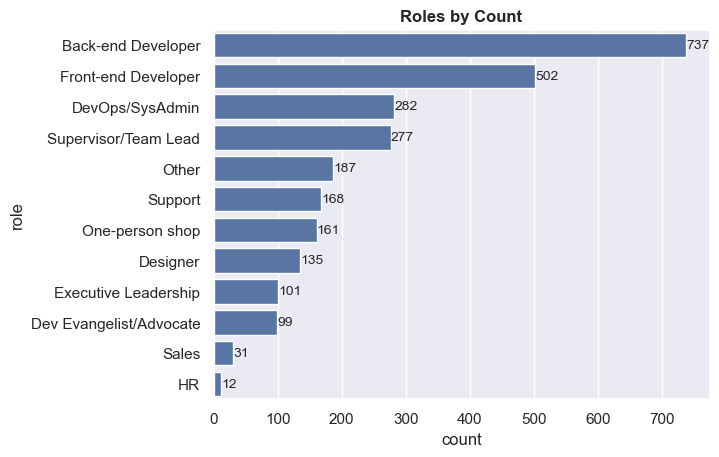

In [ ]:
sns.set_style("darkgrid")
ax = sns.barplot(df_roles, x="count", y="role")

plt.title("Roles by Count", weight="bold")
ax.bar_label(ax.containers[0], fontsize=10)

Top 2 roles in this population are **developers** and coders, those who work closely with the **technical aspects** of the industry

## 📈 3. Diagnosis Counts & Prevalence Rates

Question in use in this section:

- (#115) **If yes, what condition(s) have you been diagnosed with?**
    - Note: multi-select allowed -> *2072 total responses*
    - Only present in *2016*

### 3.1 Diagnosis Counts

We will be counting those **diagnosed** in the sample

In [103]:
query = """
        SELECT  
                AnswerText AS condition,
                COUNT(DISTINCT UserID) AS count
        FROM Answer 
        WHERE QuestionID = 115
        GROUP BY AnswerText
        ORDER BY count DESC
        """

df_conditions_all = pd.read_sql(query, con)
df_conditions_all.head()

,condition,count
0,-1,865
1,"Mood Disorder (Depression, Bipolar Disorder, etc)",412
2,"Anxiety Disorder (Generalized, Social, Phobia,...",345
3,Attention Deficit Hyperactivity Disorder,121
4,Post-traumatic Stress Disorder,69


##### Categorizing Conditions

There are *12 fixed responses* (and 1 "Other" choice) to choose from. 

To progress our analysis, I will be **categorizing** the free responses to one of the 12 fixed responses with regards to the source and in line with medical research as close as possible.

An **additional category** of conditions was made to consider those with **Autism Spectrum Disorder (ASD)**

In [ ]:
categories_dict = {
    "Mood Disorder (Depression, Bipolar Disorder, etc)": [
        "depression",
        "seasonal affective disorder",
    ],
    "Anxiety Disorder (Generalized, Social, Phobia, etc)": ["anxiety"],
    "Attention Deficit Hyperactivity Disorder": ["add", "adhd"],
    "Post-traumatic Stress Disorder": ["ptsd"],
    "Obsessive-Compulsive Disorder": ["ocd"],
    "Substance Use Disorder": ["alcohol", "drug", "substance"],
    "Personality Disorder (Borderline, Antisocial, Paranoid, etc)": [],
    "Stress Response Syndromes": [],
    "Addictive Disorder": ["sexual addiction", "addiction"],
    "Eating Disorder (Anorexia, Bulimia, etc)": [],
    "Dissociative Disorder": ["depersonalization", "dissociative"],
    "Psychotic Disorder (Schizophrenia, Schizoaffective, etc)": ["schizo", "psychosis"],
    "Autism Spectrum Disorder (ASD)": [
        "autism",
        "asperges",
        "asperger",
        "pervasive",
        "pdd",
    ],
}


def categorize_condition(text):
    if not isinstance(text, str) or not text.strip():
        return -1

    if text in categories_dict:
        return text

    text = text.lower().strip()

    drop_terms = [
        "transgender",
        "gender",
        "tinnitus",
        "traumatic brain injury",
        "sleeping disorder",
        "burn out",
        "burnout",
        "hurt",
        "haven't been formally diagnosed",
        "undiagnosed",
    ]
    if any(term in text for term in drop_terms):
        return -1

    for category, keywords in categories_dict.items():
        if any(keyword in text for keyword in keywords):
            return category

    return -1

Terms were considered dropped if they are:
- not a condition that is mentally diagnosed (burn out)
- considered more of a physical condition than a mental / neurological psychiatric disorder (traumatic brain injury)
- not at all a mental condition / disorder (transgender)
- user stated they are not diagnosed

In [105]:
df_conditions = df_conditions_all.copy()
df_conditions["condition"] = df_conditions_all["condition"].apply(categorize_condition)
df_conditions = df_conditions[df_conditions["condition"] != -1]

df_conditions = (
    df_conditions.groupby("condition", as_index=False)["count"]
    .sum()
    .sort_values(by=["count"], ascending=[False])
)

df_conditions = df_conditions.reset_index(drop=True)
len(df_conditions)

13

There are now **13 conditions / categories** of conditions

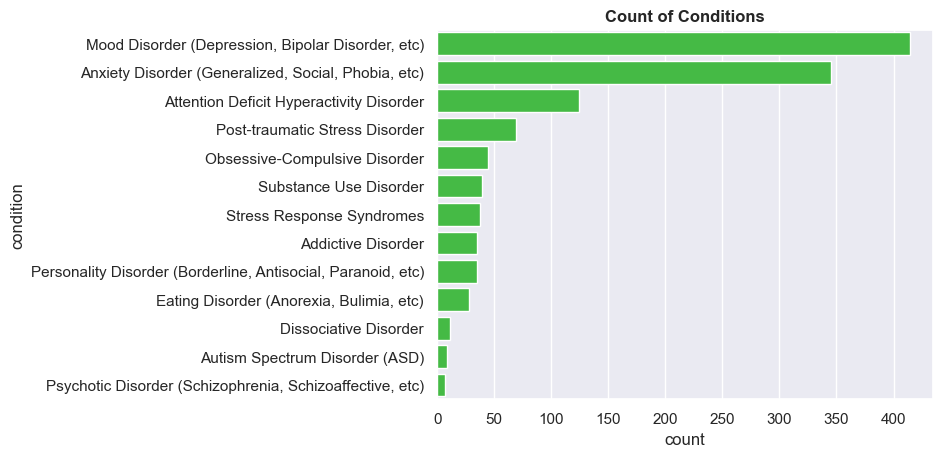

In [106]:
sns.set_style("darkgrid")

sns.barplot(df_conditions, x="count", y="condition", color="limegreen")

plt.title("Count of Conditions", weight="bold")
plt.show()

For raw counts, **Mood Disorder** and **Anxiety Disorder** have the highest numbers.

## 3.2 Overall Prevalence Rate of Different Conditions

Beyond specific counts and numbers, we will take a look at the prevalence rate of these 13 conditions. **What proportion of the population is found to be affected by these conditions?** The prevalence rate per individual disease is of focus.

The prevalence rate formula is given as: $$P = \frac{N}{T} * 100$$

Where: 

- Prevalence (proportion) (P) = Number of cases (N) ÷ Total number of people in the population (T) * 100
- n = 1,433 respondents in 2016




In [107]:
n = 1433

df_conditions["prevalence (%)"] = ((df_conditions["count"]) / 1433) * 100

#### Confidence Intervals

In [108]:
from statsmodels.stats.proportion import proportion_confint

ci = df_conditions["count"].apply(
    lambda x: proportion_confint(count=x, nobs=n, alpha=0.05, method="wilson")
)

df_conditions["ci_lower (%)"] = [x[0] * 100 for x in ci]
df_conditions["ci_upper (%)"] = [x[1] * 100 for x in ci]

df_conditions[["condition", "prevalence (%)", "ci_lower (%)", "ci_upper (%)"]]
df_conditions.head()

,condition,count,prevalence (%),ci_lower (%),ci_upper (%)
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",414,28.890440,26.602591,31.291163
1,"Anxiety Disorder (Generalized, Social, Phobia,...",345,24.075366,21.932933,26.356421
2,Attention Deficit Hyperactivity Disorder,124,8.653175,7.305810,10.221626
3,Post-traumatic Stress Disorder,69,4.815073,3.822352,6.049402
4,Obsessive-Compulsive Disorder,45,3.140265,2.355110,4.175983


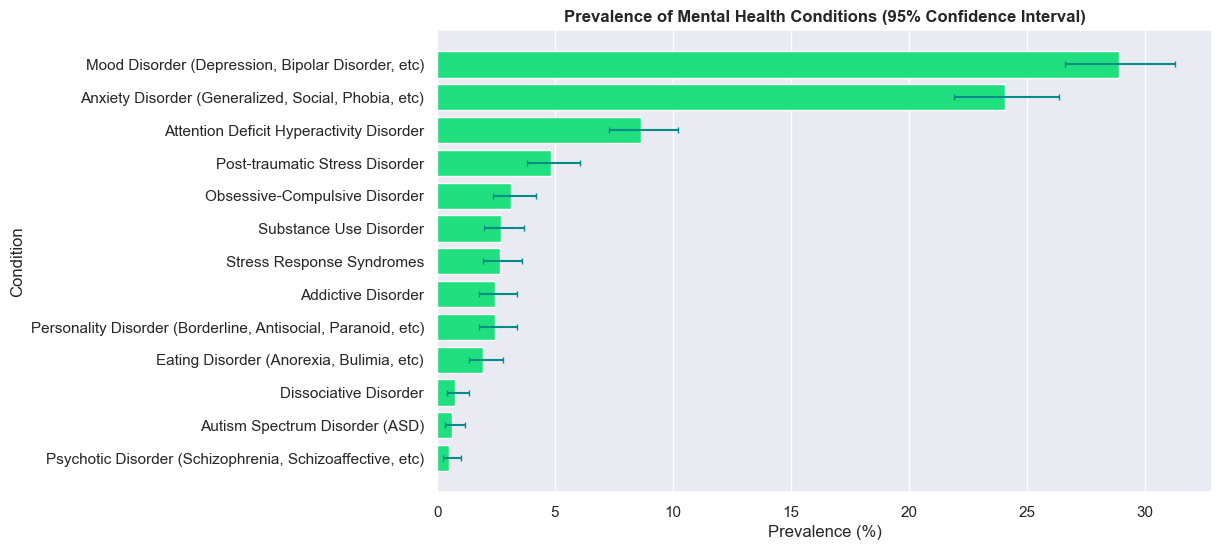

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(df_conditions, x="prevalence (%)", y="condition", color="springgreen")

plt.errorbar(
    x=df_conditions["prevalence (%)"],
    y=range(len(df_conditions)),
    xerr=[
        df_conditions["prevalence (%)"] - df_conditions["ci_lower (%)"],
        df_conditions["ci_upper (%)"] - df_conditions["prevalence (%)"],
    ],
    fmt="none",
    ecolor="darkcyan",
    capsize=2,
)

plt.title(
    "Prevalence of Mental Health Conditions (95% Confidence Interval)", weight="bold"
)
plt.xlabel("Prevalence (%)")
plt.ylabel("Condition")

The confidence intervals for overall prevalence are relatively narrow, providing a high range of certainty for the top conditions

Mood Disorders remain the most common, affecting up to 30% of respondents - about **1 in 3** respondents

---
## 3.3 Prevalence Rates Among Different Roles in Tech

In this section, we will be analyzing the prevalence rate among different roles in tech, of 3 different conditions:
1. Mood Disorder (Depression, Bipolar Disorder, etc)
2. Anxiety Disorder (Generalized, Social, Phobia, etc)
3. Attention Deficit Hyperactivity Disorder

Gathering all data on both respondents roles and conditions in 1 dataframe:

In [ ]:
query = """
        WITH roles AS (
            SELECT 
                UserID,
                AnswerText AS role
            FROM Answer
            WHERE QuestionID = 117
        ), 
        conditions AS (
            SELECT 
                UserID,
                AnswerText AS condition
            FROM Answer
            WHERE QuestionID = 115
        )
        SELECT
            r.UserID,
            r.role,
            c.condition
        FROM roles r
        LEFT JOIN conditions c
            ON c.UserID = r.UserID
        """

df_roles_conditions = pd.read_sql(query, con)
df_roles_conditions.head()

,UserID,role,condition
0,1261,Back-end Developer,-1
1,1262,Back-end Developer,"Anxiety Disorder (Generalized, Social, Phobia,..."
2,1262,Back-end Developer,"Mood Disorder (Depression, Bipolar Disorder, etc)"
3,1262,Front-end Developer,"Anxiety Disorder (Generalized, Social, Phobia,..."
4,1262,Front-end Developer,"Mood Disorder (Depression, Bipolar Disorder, etc)"


Grouping all by roles + certain conditions and their count into a focused dataframe

In [111]:
df_roles_conditions["condition"] = df_roles_conditions["condition"].apply(
    categorize_condition
)

focus_categories = [
    "Mood Disorder (Depression, Bipolar Disorder, etc)",
    "Anxiety Disorder (Generalized, Social, Phobia, etc)",
    "Attention Deficit Hyperactivity Disorder",
]

df_focus = df_roles_conditions[df_roles_conditions["condition"].isin(focus_categories)]

# n = number of diagnosed employees in this role
role_counts = (
    df_focus.groupby(["role", "condition"])["UserID"]
    .nunique()
    .reset_index(name="count")
)

# t = total number of employees in this role
role_totals = df_roles.rename(columns={"count": "total_users"})

df_role_prevalence = role_counts.merge(role_totals, on="role")
df_role_prevalence["prevalence (%)"] = (
    df_role_prevalence["count"] / df_role_prevalence["total_users"]
) * 100

Confidence Intervals

In [112]:
ci = df_role_prevalence.apply(
    lambda row: proportion_confint(
        count=row["count"], nobs=row["total_users"], alpha=0.10, method="wilson"
    ),
    axis=1,
)

df_role_prevalence["ci_lower (%)"] = [x[0] * 100 for x in ci]
df_role_prevalence["ci_upper (%)"] = [x[1] * 100 for x in ci]
df_role_prevalence.head()

,role,condition,count,total_users,prevalence (%),ci_lower (%),ci_upper (%)
0,Back-end Developer,"Anxiety Disorder (Generalized, Social, Phobia,...",168,737,22.795115,20.355549,25.433691
1,Back-end Developer,Attention Deficit Hyperactivity Disorder,64,737,8.683853,7.125228,10.544714
2,Back-end Developer,"Mood Disorder (Depression, Bipolar Disorder, etc)",196,737,26.594301,24.006412,29.353407
3,Designer,"Anxiety Disorder (Generalized, Social, Phobia,...",43,135,31.851852,25.668195,38.748633
4,Designer,Attention Deficit Hyperactivity Disorder,22,135,16.296296,11.739421,22.177545


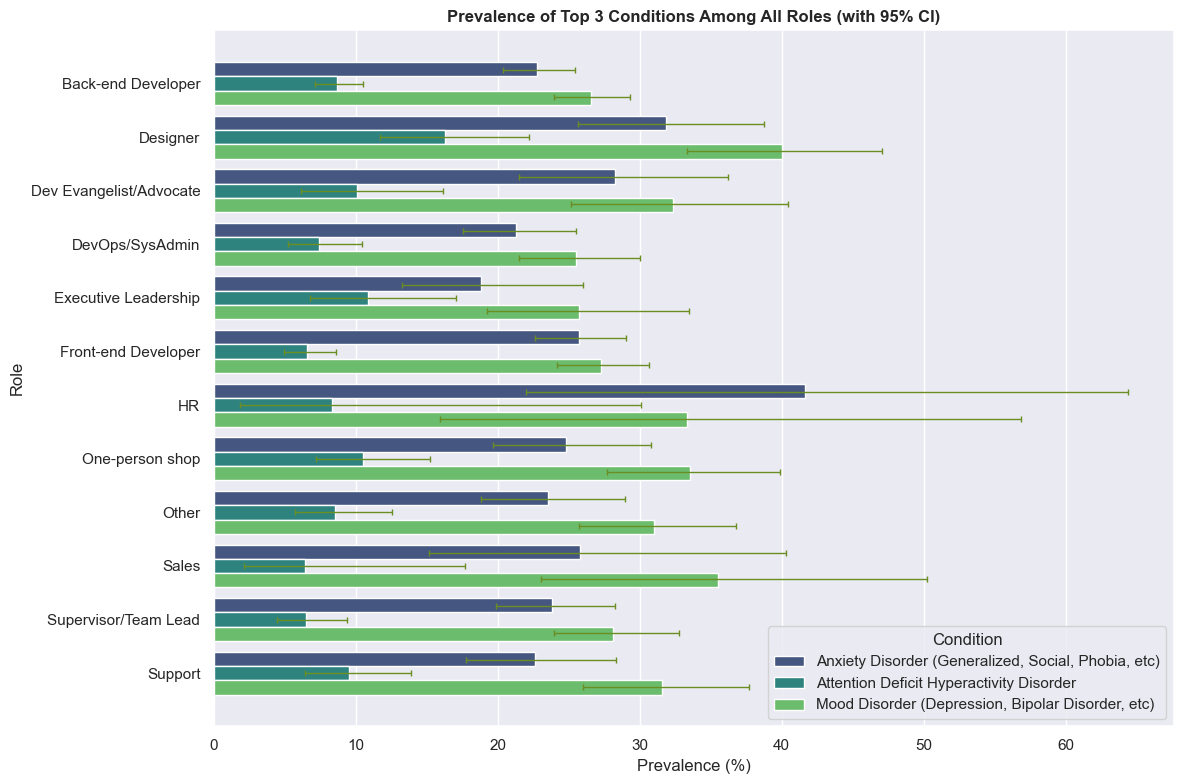

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(
    df_role_prevalence, x="prevalence (%)", y="role", hue="condition", palette="viridis"
)

roles = df_role_prevalence["role"].unique()
conditions = df_role_prevalence["condition"].unique()

# Offsets for vertical spacing and aligning CIs to bars
bar_height = 0.25
offsets = np.linspace(-bar_height, bar_height, len(conditions))

for i, cond in enumerate(conditions):
    subset = df_role_prevalence[df_role_prevalence["condition"] == cond]
    subset = subset.set_index("role").reindex(roles)

    y_positions = np.arange(len(roles)) + offsets[i]
    xerr = [
        subset["prevalence (%)"] - subset["ci_lower (%)"],
        subset["ci_upper (%)"] - subset["prevalence (%)"],
    ]

    plt.errorbar(
        x=subset["prevalence (%)"],
        y=y_positions,
        xerr=xerr,
        fmt="none",
        ecolor="olivedrab",
        capsize=2,
        lw=1,
    )

plt.title("Prevalence of Top 3 Conditions Among All Roles (with 95% CI)", weight="bold")
plt.xlabel("Prevalence (%)")
plt.ylabel("Role")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

*(Note the wide length of confidence intervals and high uncertainty due to smaller sample sizes of roles)*

* Mood disorders remain the most prevalent
* Some roles have noticeable rates of **Anxiety disorders** inching **closer** to the rate of Mood disorders

---
### 🏢 4 Company Size Factor
#### Impact and Correlations of **Company Size** to: Presence of **Mental Health Benefits, Resources, and Discussions** in the Workplace

| **Variable** | **Question** |
|---------------|--------------|
| **Company Size** | (#8) How many employees does your company or organization have? |
| **Benefits** | (#10) Does your employer provide mental health benefits as part of healthcare coverage? |
| **Formal Discussions on Mental Health** | (#15) Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)? |
| **Resources** | (#16) Does your employer offer resources to learn more about mental health disorders and options for seeking help? |




There are also questions of **scaling and perception**: rating the importance of mental health placed by the company, and the individual's perception on how the tech industry handles mental health:
| **Variable** | **Question** |
|---------------|--------------|
| Importance to the Company | (#65) Overall, how much importance does your employer place on mental health? [0 - lowest to 10 highest] |
| Perception on Tech Industry and Mental Support | (#85) Overall, how well do you think the tech industry supports employees with mental health issues? [1 - lowest to 5 highest] |

*(For this section we are observing 2017 - 2019 responses where all questions above are simultaneously present in the surveys. In lieue of this we will exclude 2014 and 2016.)*

The query that follows below is of considerable length but its usage simply **gathers the responses per question above**, with a **CTE per question**:

In [ ]:
query = """
        WITH company_size AS (
                SELECT 
                        SurveyID AS year, 
                        UserID,
                        AnswerText AS company_size, 
                        CASE 
                                WHEN AnswerText = '1-5' THEN 1
                                WHEN AnswerText = '6-25' THEN 2
                                WHEN AnswerText = '26-100' THEN 3
                                WHEN AnswerText = '100-500' THEN 4
                                WHEN AnswerText = '500-1000' THEN 5
                                WHEN AnswerText = 'More than 1000' THEN 6
                        END AS size_num
                FROM Answer 
                WHERE QuestionID = 8 AND AnswerText != -1 
        ), 
        
        benefits AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CASE
                                WHEN AnswerText = 'Yes' THEN 1
                                WHEN AnswerText = 'No' THEN 0
                        END AS mh_benefits
                FROM Answer
                WHERE QuestionID = 10
                        AND AnswerText IN ('Yes', 'No')
        ), 
        
        discussions AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CASE
                                WHEN AnswerText = 'Yes' THEN 1
                                WHEN AnswerText = 'No' THEN 0
                        END AS mh_discussed
                FROM Answer
                WHERE QuestionID = 15
                        AND AnswerText IN ('Yes', 'No')
        ), 
        
        resources AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CASE
                                WHEN AnswerText = 'Yes' THEN 1
                                WHEN AnswerText = 'No' THEN 0
                        END AS mh_resources
                FROM Answer
                WHERE QuestionID = 16
                        AND AnswerText IN ('Yes', 'No')
        ), 
        
        importance AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CAST(AnswerText AS INTEGER) AS mh_importance
                FROM Answer
                WHERE QuestionID = 65
                        AND AnswerText != -1
        ), 
        
        perception AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CAST(AnswerText AS INTEGER) AS industry_perception
                FROM Answer
                WHERE QuestionID = 85
                        AND AnswerText != -1
        ) 
        
        SELECT
                c.UserID,
                c.year,
                c.company_size,
                c.size_num,
                b.mh_benefits,
                d.mh_discussed,
                r.mh_resources,
                i.mh_importance,
                p.industry_perception
        FROM company_size AS c
        JOIN benefits AS b 
                ON c.UserID = b.UserID AND c.year = b.year
        JOIN discussions AS d
                ON c.UserID = d.UserID AND c.year = d.year
        JOIN resources AS r
                ON c.UserID = r.UserID AND c.year = r.year
        JOIN importance AS i
                ON c.UserID = i.UserID AND c.year = i.year
        JOIN perception AS p
                ON c.UserID = p.UserID AND c.year = p.year
        WHERE c.year != 2014
        ORDER BY c.year
        """

df_tech = pd.read_sql(query, con)
df_tech.head()

,UserID,year,company_size,size_num,mh_benefits,mh_discussed,mh_resources,mh_importance,industry_perception
0,2695,2017,100-500,4,1,0,0,2,2
1,2700,2017,6-25,2,1,0,0,10,2
2,2701,2017,26-100,3,1,0,0,8,2
3,2704,2017,100-500,4,1,0,0,0,1
4,2706,2017,More than 1000,6,0,0,0,7,4


In [115]:
df_tech.company_size.value_counts()

company_size
More than 1000    215
100-500           172
26-100            113
6-25               98
500-1000           59
1-5                14
Name: count, dtype: int64

Majority come from the largest possible company size next to middle-larger companies.



Gathering all the responses, as well as transforming the company size column to an additional numerical feature, will allow us to inspect correlations between all these features in a heatmap:

### 4.1 Correlations

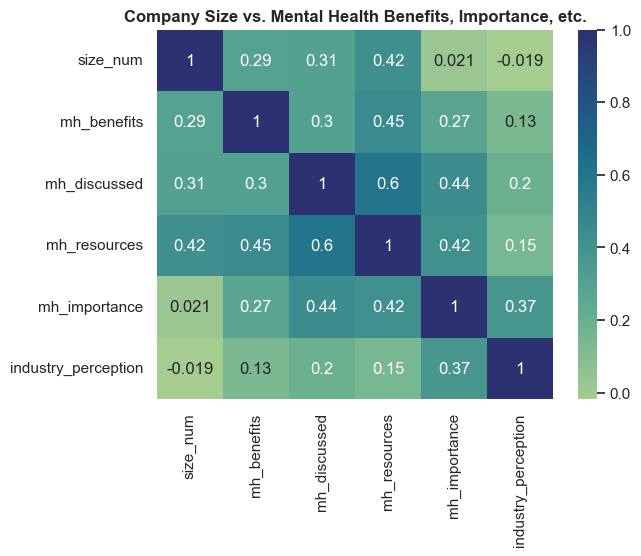

In [ ]:
df_tech_dropped = df_tech.drop(columns=["UserID", "year", "company_size"])
sns.heatmap(df_tech_dropped.corr(), annot=True, cmap="crest")
plt.title("Company Size vs. Mental Health Benefits, Importance, etc.", weight="bold")

### Correlation of Company Size, Mental Health Resources and Perceptions

##### 📈 **Company size** does have distinct **moderate to slight positive correlations** with:


| Variable          | Correlation | Analysis |
|------------------------|-----------------|--------------|
| **Resources**       | ***0.42***        | Larger companies are more likely to provide mental health resources |
| **Discussions** & **Benefits**       | 0.31, 0.29      | Larger companies tend to initiate formal discussions on mental health; hand in hand with providing mental health benefits for employees |


##### 📉 On the other hand, company size has **little to no correlation** with:

| Variable          | Correlation | Analysis |
|------------------------|-----------------|--------------|
| **Importance of mental health**      | *0.02*        | Close to 0, the size of the company has little to no correlation on how employees feel their company prioritizes mental health |
| **Industry Perception** | *-0.02*       | Company size does not necessarily correlate with employees' view on tech industry's support of mental health  |

While larger companies tend to present resources and benefits, it does not correlate with an employee's bearing that their company places importance on mental health.

**Between other variables:**
* Presence of one resource strongly correlates with the presence of others (e.g. Discussions & Resources (0.60) when resources are offered, discussions come hand in hand)
* **Industry perception** shows the lowest correlations with all other variables present, suggesting that what companies offer in terms of mental health **does not shift views on the tech industry as a whole.**

### 4.2 Openness to Mental Health - Seeking Help Over the Years

* Have you ever sought treatment for a mental health disorder from a mental health professional?

In [117]:
query = """
        SELECT 
            SurveyID AS year,
            AnswerText AS help_sought,
            COUNT(*) AS count,
            ROUND(
                COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY SurveyID) * 100, 0
            ) AS percent
        FROM Answer
        WHERE QuestionID = 7
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, AnswerText
        """

df_help = pd.read_sql(query, con)
df_help.head()

,year,help_sought,count,percent
0,2014,0,623,49.0
1,2014,1,637,51.0
2,2016,0,594,41.0
3,2016,1,839,59.0
4,2017,0,300,40.0


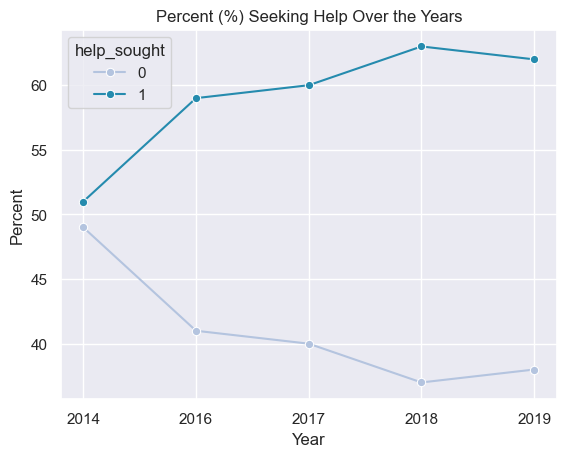

In [ ]:
sns.lineplot(
    df_help,
    x=df_help["year"].astype(str),
    y="percent",
    hue="help_sought",
    palette="PuBuGn",
    marker="o",
)

plt.title("Percent (%) Seeking Help Over the Years")
plt.xlabel("Year")
plt.ylabel("Percent")

* A larger part of the surveyed population had sought mental health help as the years went by
* It is a nice trend to see help being sought more and more

---
## 5. Conclusion
### 5.1 Suggestions for Research
* Standardize questions
* Diversify samples and population
* Enforce fixed responses for questions relating to responses that should be of closed-answer nature

### 5.2 Final Insights

#### Demographics & Biases

* Distinct **sampling bias** in this population, with specific types of people over-represented in the sample
    * With the population having prominent numbers in gender, race, and country demographics: male, white, american
* **Consistency errors** from the sampling body
    * Missing the year 2015 = 1 year's gap in data
    * Questions are not standardized and varied heavily in number of questions & what was asked every year

#### Mental Conditions

* **Most prominent mental condition was Mood Disorder** with a *29% prevalence rate* across this population
* Looking at different roles in tech:
    * **Different roles could have higher prevalence in other** conditions but Mood Disorder is still prevalent

#### Correlations
* **Larger size of companies** correlates to **more mental health benefits, resources, etc**
* Presence of the above **did not however, make employees actually feel that their company placed importance on mental health**
    * May be that mental health resources offered by the company are more of formalities
    * In terms of environment and true support that employees felt, it does not correlate with what the company offers
#####
* Industry perception overall of tech is not shifted by the mental health resources presented by a company

Overall,

* **Despite provided benefits and resources:**
    * **more efforts are needed to better support mental health in to the industry**
    * **more efforts than the above are needed for employees to feel that their mental health is of importance to their company**